In [91]:
#IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re

In [92]:
data = pd.read_csv('train.csv')
data.head(10)

,id,prompt,answer
0,00066667,"In Alice's Wonderland, a secret bit manipulati...",10010111
1,000b53cf,"In Alice's Wonderland, a secret bit manipulati...",01000011
2,00189f6a,"In Alice's Wonderland, secret encryption rules...",cat imagines book
3,001b24c4,"In Alice's Wonderland, numbers are secretly co...",XXXVIII
4,001c63cb,"In Alice's Wonderland, secret encryption rules...",wizard creates secret
5,00208201,"In Alice's Wonderland, a secret unit conversio...",16.65
6,0031df9c,"In Alice's Wonderland, a secret bit manipulati...",00110100
7,0040ff76,"In Alice's Wonderland, the gravitational const...",154.62
8,00457d26,"In Alice's Wonderland, a secret set of transfo...",@&
9,00463d04,"In Alice's Wonderland, the gravitational const...",50.51


In [93]:
print(data.info())
print(data.describe())
print("\n\n")
print(data.prompt[1])

<class 'pandas.DataFrame'>
RangeIndex: 9500 entries, 0 to 9499
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      9500 non-null   str  
 1   prompt  9500 non-null   str  
 2   answer  9500 non-null   str  
dtypes: str(3)
memory usage: 222.8 KB
None
              id                                             prompt    answer
count       9500                                               9500      9500
unique      9500                                               9500      5921
top     00066667  In Alice's Wonderland, a secret bit manipulati...  00000000
freq           1                                                  1       103



In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.

Here are some examples of input -> output:
10001110 -> 00100110
10011001 -> 0

7
0       7
1       8
2       0
3       3
4       0
       ..
9495    7
9496    0
9497    0
9498    0
9499    0
Name: n_examples, Length: 9500, dtype: int64

MAX NUMBER OF EXAMPLES IN A PROMPT: 
id                                                     0031df9c
prompt        In Alice's Wonderland, a secret bit manipulati...
answer                                                 00110100
n_examples                                                    9
Name: 6, dtype: object


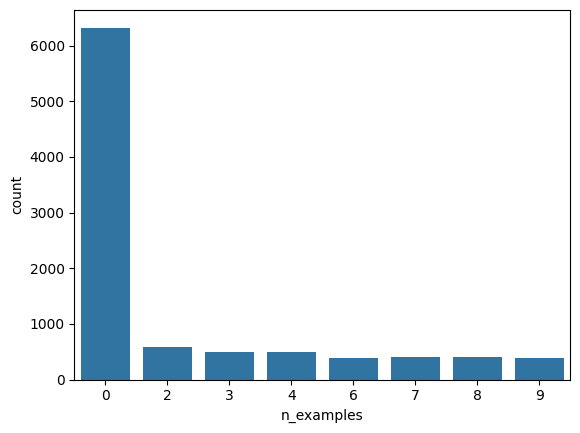

In [94]:
def n_shot_count(prompt):    
    example_count_pattern = r'\d+\s*->'
    example_count_matches = re.findall(example_count_pattern, prompt)

    return max(example_count_matches.__len__() - 1 ,0)
    
    
print(n_shot_count(data.prompt[0]))
data['n_examples'] = data['prompt'].apply(n_shot_count)
print(data.loc[:,'n_examples'])

sns.countplot(x='n_examples', data=data)

print('\nMAX NUMBER OF EXAMPLES IN A PROMPT: ')
print(data.loc[data['n_examples'] == data.n_examples.max(), :].iloc[0])

### BASIC DATA INTEGRITY AND QUALITY CHECKS

Train set shape: (9500, 3)
Test set shape: (3, 2)

Train missing values:
 id        0
prompt    0
answer    0
dtype: int64

Test missing values:
 id        0
prompt    0
dtype: int64

Duplicate prompts in train: 0

Prompt length statistics:
 count    9500.000000
mean      301.515895
std       104.265311
min       177.000000
25%       209.000000
50%       281.000000
75%       371.000000
max       510.000000
Name: prompt_len, dtype: float64

Answer length statistics:
 count    9500.000000
mean        8.393789
std         8.035097
min         1.000000
25%         4.000000
50%         5.000000
75%         8.000000
max        39.000000
Name: answer_len, dtype: float64


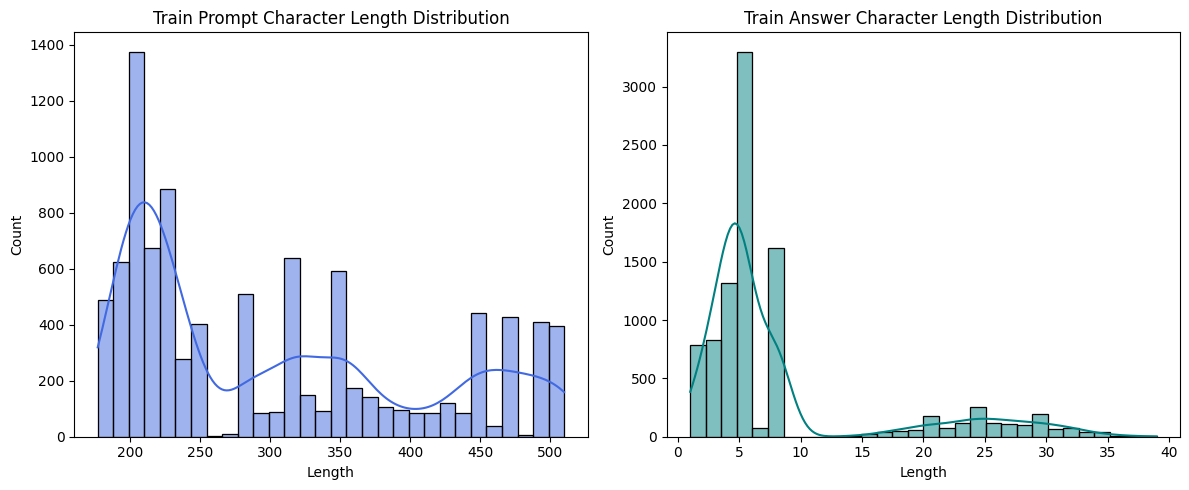

In [95]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("Train set shape:", train_df.shape)
print("Test set shape:", test_df.shape)
print("\nTrain missing values:\n", train_df.isnull().sum())
print("\nTest missing values:\n", test_df.isnull().sum())

print("\nDuplicate prompts in train:", train_df['prompt'].duplicated().sum())

train_df['prompt_len'] = train_df['prompt'].str.len()
train_df['answer_len'] = train_df['answer'].str.len()


test_df['prompt_len'] = test_df['prompt'].str.len()
test_df['prompt_len'] = test_df['prompt'].str.len()

print("\nPrompt length statistics:\n", train_df['prompt_len'].describe())
print("\nAnswer length statistics:\n", train_df['answer_len'].describe())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(train_df['prompt_len'], kde=True, color='royalblue', bins=30)
plt.title("Train Prompt Character Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.histplot(train_df['answer_len'], kde=True, color='teal', bins=30)
plt.title("Train Answer Character Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

###  TASK CATEGORIZATION AND TAXONOMY

Train task type distributions:
task_type
Bit Manipulation        1602
Physics Gravity         1597
Unit Conversion         1594
Text Encryption         1576
Numeral Conversion      1576
Equations & Symbolic    1555
Name: count, dtype: int64

Test task type distributions:
task_type
Bit Manipulation    2
Text Encryption     1
Name: count, dtype: int64


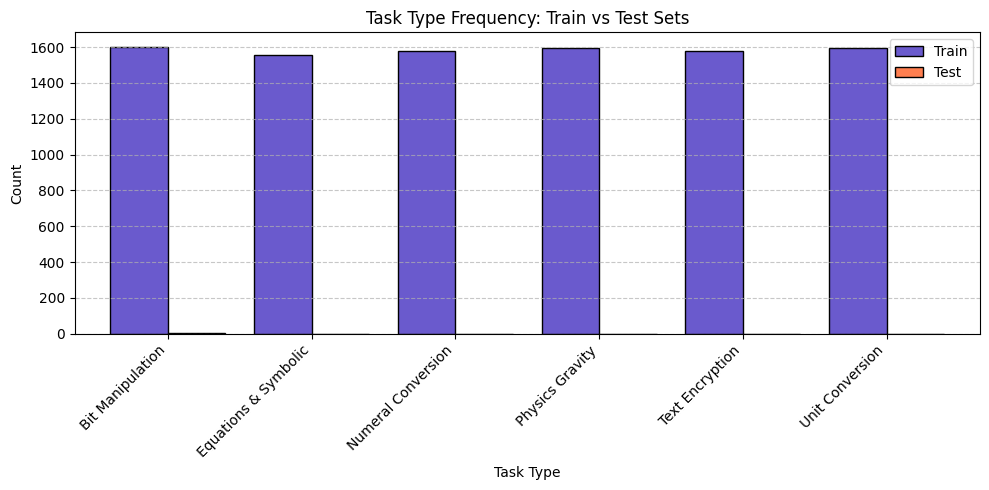

In [96]:
def classify_task(prompt):
    if "bit manipulation" in prompt:
        return "Bit Manipulation"
    elif "encryption rules" in prompt:
        return "Text Encryption"
    elif "numeral system" in prompt:
        return "Numeral Conversion"
    elif "unit conversion" in prompt:
        return "Unit Conversion"
    elif "applied to equations" in prompt:
        return "Equations & Symbolic"
    elif "gravitational constant" in prompt:
        return "Physics Gravity"
    else:
        return "Unknown"

train_df['task_type'] = train_df['prompt'].apply(classify_task)
test_df['task_type'] = test_df['prompt'].apply(classify_task)

print("Train task type distributions:")
print(train_df['task_type'].value_counts())
print("\nTest task type distributions:")
print(test_df['task_type'].value_counts())

plt.figure(figsize=(10, 5))
task_counts_df = pd.DataFrame({
    'Train': train_df['task_type'].value_counts(),
    'Test': test_df['task_type'].value_counts()
}).fillna(0)
task_counts_df.plot(kind='bar', color=['slateblue', 'coral'], edgecolor='black', width=0.8, ax=plt.gca())
plt.title("Task Type Frequency: Train vs Test Sets")
plt.xlabel("Task Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### SHOT COUNT AND FEW-SHOT EXAMPLES DISTRIBUTION

Train Shot Count distribution per task:
                       count      mean       std  min  25%   50%   75%   max
task_type                                                                   
Bit Manipulation      1602.0  9.503121  1.110532  8.0  9.0  10.0  10.0  11.0
Equations & Symbolic  1555.0  4.025080  0.807789  3.0  3.0   4.0   5.0   5.0
Numeral Conversion    1576.0  3.947970  0.824903  3.0  3.0   4.0   5.0   5.0
Physics Gravity       1597.0  4.049468  0.810756  3.0  3.0   4.0   5.0   5.0
Text Encryption       1576.0  4.000000  0.809468  3.0  3.0   4.0   5.0   5.0
Unit Conversion       1594.0  3.983061  0.817473  3.0  3.0   4.0   5.0   5.0


C:\Users\Hoang\AppData\Local\Temp\ipykernel_29708\2326933328.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='task_type', y='n_shots', data=train_df, palette='Set2')


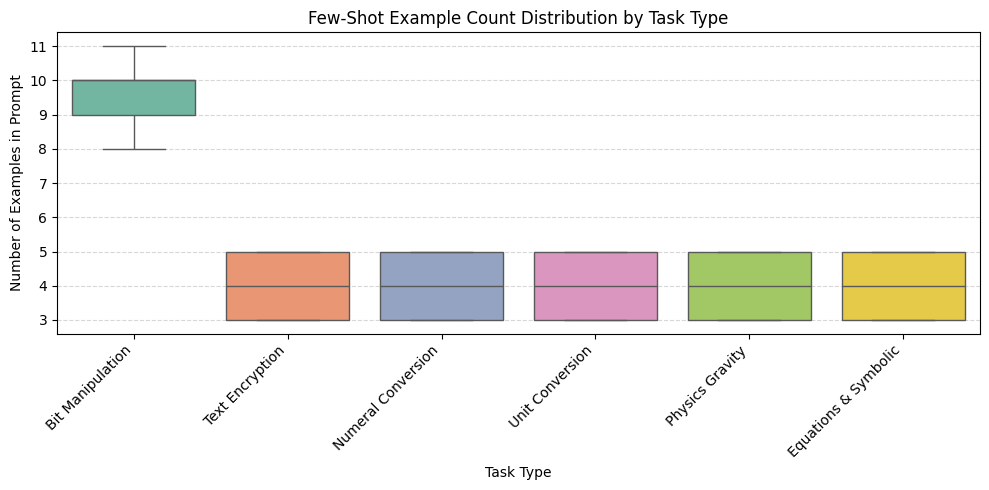

In [97]:
def extract_shot_count(prompt):
    lines = [line.strip() for line in prompt.split('\n') if line.strip()]
    operators = ['->', 'becomes', '=', 'For t =']
    example_count = 0
    for line in lines:
        is_example = any(op in line for op in operators)
        is_instruction = any(word in line.lower() for word in ["determine", "convert the following", "decrypt the following", "write the number", "now,"])
        if is_example and not is_instruction:
            example_count += 1
    return example_count

train_df['n_shots'] = train_df['prompt'].apply(extract_shot_count)
test_df['n_shots'] = test_df['prompt'].apply(extract_shot_count)

print("Train Shot Count distribution per task:")
print(train_df.groupby('task_type')['n_shots'].describe())

plt.figure(figsize=(10, 5))
sns.boxplot(x='task_type', y='n_shots', data=train_df, palette='Set2')
plt.title("Few-Shot Example Count Distribution by Task Type")
plt.xlabel("Task Type")
plt.ylabel("Number of Examples in Prompt")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### BIT MANIPULATION DEEP DIVE (GF2 LINEARITY & PATTERNS)

Percentage of linear bit manipulation tasks (first 50 samples): 30.00%


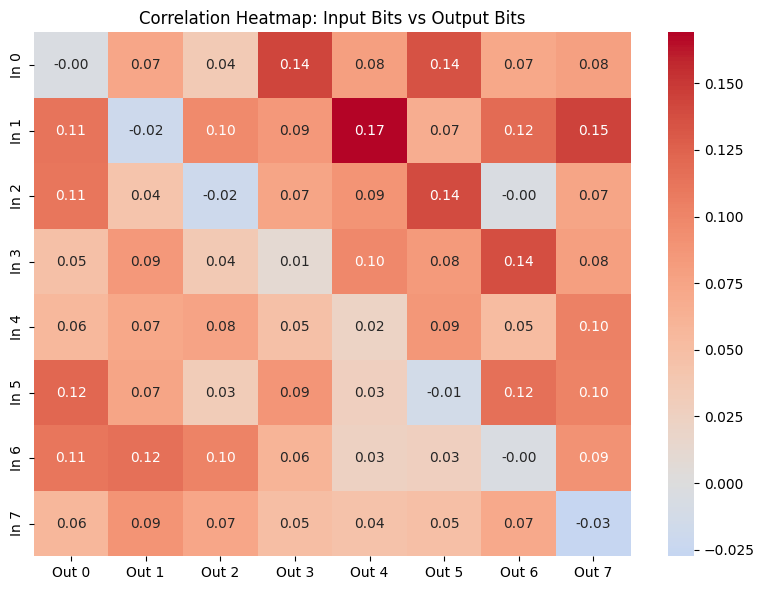

In [98]:
bit_df = train_df[train_df['task_type'] == 'Bit Manipulation'].copy()

def parse_bit_examples(prompt):
    pattern = r'([01]{8})\s*->\s*([01]{8})'
    examples = re.findall(pattern, prompt)
    return [(np.array([int(c) for c in inp]), np.array([int(c) for c in out])) for inp, out in examples]

def check_gf2_linearity(examples):
    if len(examples) < 9: 
        return False

    X = np.stack([x for x, y in examples])
    Y = np.stack([y for x, y in examples])
    X_aug = np.hstack([X, np.ones((X.shape[0], 1))])
    
    is_linear = True
    for col in range(8):
        y_col = Y[:, col]
        found_w = False
        for i in range(512):
            w = np.array([(i >> j) & 1 for j in range(9)])
            if np.array_equal((X_aug @ w) % 2, y_col):
                found_w = True
                break
        if not found_w:
            is_linear = False
            break
            
    return is_linear

linear_count = 0
for idx, row in bit_df.head(50).iterrows():
    examples = parse_bit_examples(row['prompt'])
    if check_gf2_linearity(examples):
        linear_count += 1
        
print(f"Percentage of linear bit manipulation tasks (first 50 samples): {linear_count/50 * 100:.2f}%")

all_inputs = []
all_outputs = []
for idx, row in bit_df.head(200).iterrows():
    examples = parse_bit_examples(row['prompt'])
    for inp, out in examples:
        all_inputs.append(inp)
        all_outputs.append(out)
if all_inputs:
    X_bits = np.stack(all_inputs)
    Y_bits = np.stack(all_outputs)
    # Compute correlation matrix between input bits and output bits
    corr_matrix = np.zeros((8, 8))
    for i in range(8):
        for j in range(8):
            corr_matrix[i, j] = np.corrcoef(X_bits[:, i], Y_bits[:, j])[0, 1]
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                xticklabels=[f"Out {j}" for j in range(8)], yticklabels=[f"In {i}" for i in range(8)])
    plt.title("Correlation Heatmap: Input Bits vs Output Bits")
    plt.tight_layout()
    plt.show()

### TRAIN-TEST ALIGNMENT & OUT-OF-DISTRIBUTION CHECKS

Task types in test but NOT in train: set()

Prompt lengths comparison (Mean/Std):
Train prompt length: 301.52 +/- 104.27
Test prompt length: 471.67 +/- 15.82


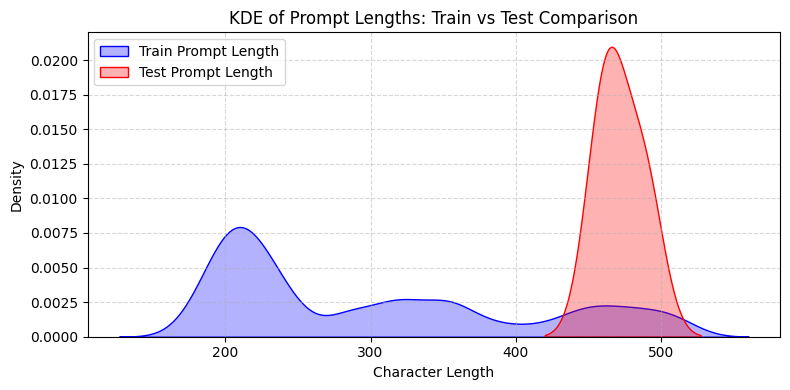

In [99]:
unseen_tasks = set(test_df['task_type'].unique()) - set(train_df['task_type'].unique())
print("Task types in test but NOT in train:", unseen_tasks)

print("\nPrompt lengths comparison (Mean/Std):")
print(f"Train prompt length: {train_df['prompt_len'].mean():.2f} +/- {train_df['prompt_len'].std():.2f}")
print(f"Test prompt length: {test_df['prompt_len'].mean():.2f} +/- {test_df['prompt_len'].std():.2f}")


plt.figure(figsize=(8, 4))
sns.kdeplot(train_df['prompt_len'], label='Train Prompt Length', fill=True, color='blue', alpha=0.3)
sns.kdeplot(test_df['prompt_len'], label='Test Prompt Length', fill=True, color='red', alpha=0.3)
plt.title("KDE of Prompt Lengths: Train vs Test Comparison")
plt.xlabel("Character Length")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### GLOBAL ANSWER TYPE TAXONOMY

Answer category counts in training set:
answer_category
Numeric Float      3879
Binary (8-bit)     1602
Text Sentence      1576
Roman Numeral      1576
Symbolic String     867
Name: count, dtype: int64


C:\Users\Hoang\AppData\Local\Temp\ipykernel_29708\4155488057.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='answer_category', data=train_df, palette='Set1', edgecolor='black')


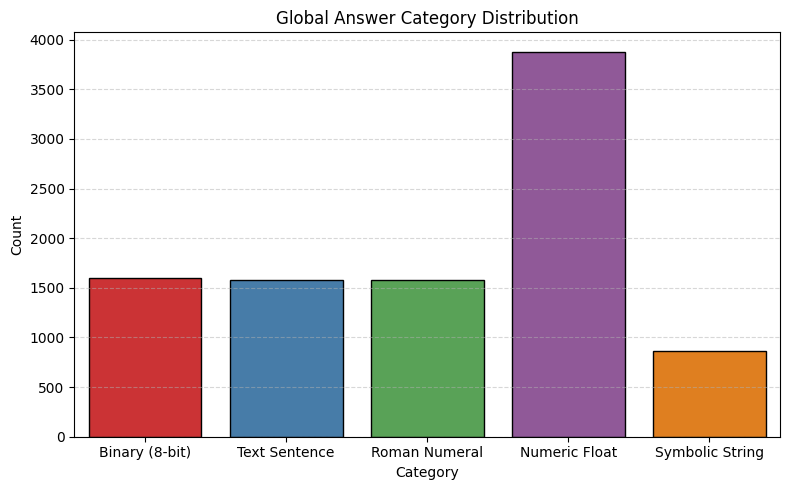

In [100]:
def categorize_answer(ans):
    ans = str(ans).strip()
    if re.match(r'^[01]{8}$', ans):
        return "Binary (8-bit)"
    if re.match(r'^[IVXLCDMivxlcdm]+$', ans):
        return "Roman Numeral"
    try:
        float(ans)
        return "Numeric Float"
    except ValueError:
        pass
    if " " in ans:
        return "Text Sentence"
    return "Symbolic String"

train_df['answer_category'] = train_df['answer'].apply(categorize_answer)
print("Answer category counts in training set:")
print(train_df['answer_category'].value_counts())

# Plot the distribution of answer categories
plt.figure(figsize=(8, 5))
sns.countplot(x='answer_category', data=train_df, palette='Set1', edgecolor='black')
plt.title("Global Answer Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### GLOBAL PROMPT CHARACTER AND VOCABULARY ANALYSIS

Unique character counts per task type:
 - Bit Manipulation: 44 unique characters
 - Text Encryption: 39 unique characters
 - Numeral Conversion: 49 unique characters
 - Unit Conversion: 42 unique characters
 - Physics Gravity: 46 unique characters
 - Equations & Symbolic: 65 unique characters

Character set overlap between Bit Manipulation and Equations: 33 characters
Shared characters: ['\n', ' ', "'", ',', '-', '.', '0', '1', '8', ':', '>', 'A', 'I', 'N', 'W', 'a', 'c', 'd', 'e', 'f', 'h', 'i', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'w', 'x']

Top 20 most frequent non-stopword tokens in prompts:
 - m: 14410
 - wonderland: 11175
 - alices: 9500
 - now: 9500
 - t: 8064
 - s: 8064
 - distance: 8064
 - secret: 6752
 - some: 6351
 - becomes: 6349
 - examples: 6309
 - bit: 4806
 - here: 4775
 - determine: 4754
 - or: 3204
 - output: 3204
 - example: 3191
 - numbers: 3178
 - secretly: 3173
 - given: 3173


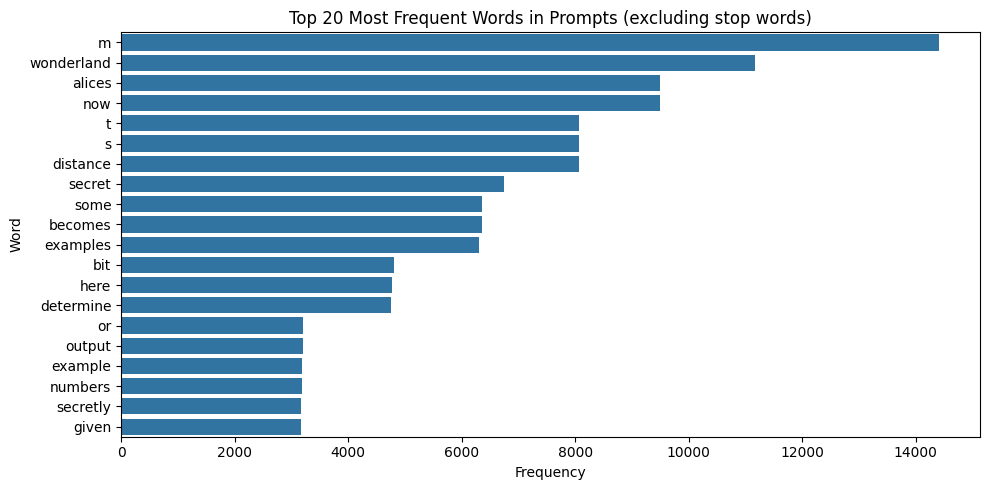

In [101]:
task_char_sets = {}
for task in train_df['task_type'].unique():
    subset = train_df[train_df['task_type'] == task]
    all_text = "".join(subset['prompt'])
    task_char_sets[task] = set(all_text)

print("Unique character counts per task type:")
for task, char_set in task_char_sets.items():
    print(f" - {task}: {len(char_set)} unique characters")

bit_chars = task_char_sets.get("Bit Manipulation", set())
eq_chars = task_char_sets.get("Equations & Symbolic", set())
overlap = bit_chars.intersection(eq_chars)
print(f"\nCharacter set overlap between Bit Manipulation and Equations: {len(overlap)} characters")
print("Shared characters:", sorted(list(overlap)))

from collections import Counter
stop_words = {'the', 'in', 'a', 'of', 'and', 'to', 'for', 'is', 'on', 'are', 'were', 'was', 'be', 'by', 'at', 'with', 'from', 'as', 'an'}
all_words = []
for prompt in train_df['prompt']:
    words = re.sub(r'[^a-zA-Z\s]', '', prompt.lower()).split()
    all_words.extend([w for w in words if w not in stop_words])

word_freq = Counter(all_words).most_common(20)
print("\nTop 20 most frequent non-stopword tokens in prompts:")
for word, count in word_freq:
    print(f" - {word}: {count}")

words, counts = zip(*word_freq)
plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts), y=list(words))
plt.title("Top 20 Most Frequent Words in Prompts (excluding stop words)")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()


### TOKENIZATION AND VOCABULARY ANALYSIS

Active Tokenizer for Analysis: Tiktoken (GPT-2 Encoding)

Token count statistics per task type:
                       count        mean        std    min    25%    50%  \
task_type                                                                  
Bit Manipulation      1602.0  133.114232   9.602210  110.0  125.0  132.0   
Equations & Symbolic  1555.0   64.828296   8.411442   51.0   59.0   65.0   
Numeral Conversion    1576.0   56.042513   4.481082   48.0   52.0   56.0   
Physics Gravity       1597.0  106.742016  12.161345   91.0   91.0  106.0   
Text Encryption       1576.0  124.427665  19.251349   85.0  109.0  123.0   
Unit Conversion       1594.0   64.847553   7.357261   56.0   56.0   65.0   

                        75%    max  
task_type                           
Bit Manipulation      141.0  153.0  
Equations & Symbolic   71.0   86.0  
Numeral Conversion     60.0   66.0  
Physics Gravity       121.0  121.0  
Text Encryption       140.0  184.0  
Unit Conversion        74.0   74.0  

C:\Users\Hoang\AppData\Local\Temp\ipykernel_29708\3195618878.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='task_type', y='token_count', data=train_df, palette='muted')


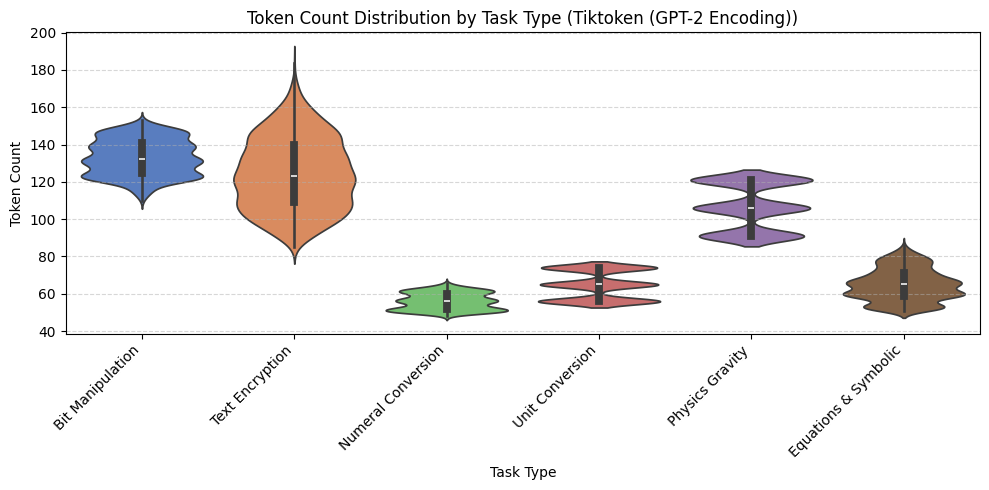


Sample symbolic prompt 1 tokenization:
 - Character length: 196
 - Token count: 69
 - Sample tokens/words extracted: ['818', '14862', '338', '42713', '11', '257', '3200', '900', '286', '13389', '3173', '318', '5625', '284', '27490'] ... (truncated)

Sample symbolic prompt 2 tokenization:
 - Character length: 196
 - Token count: 67
 - Sample tokens/words extracted: ['818', '14862', '338', '42713', '11', '257', '3200', '900', '286', '13389', '3173', '318', '5625', '284', '27490'] ... (truncated)


In [102]:
subword_tokenizer = None
tokenizer_name = "None"

try:
    import tiktoken
    enc = tiktoken.get_encoding("gpt2")
    subword_tokenizer = lambda text: enc.encode(text)
    tokenizer_name = "Tiktoken (GPT-2 Encoding)"
except ImportError:
    try:
        from transformers import GPT2TokenizerFast
        tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
        subword_tokenizer = lambda text: tokenizer.encode(text)
        tokenizer_name = "Transformers Library (GPT-2 Tokenizer)"
    except ImportError:
        import nltk
        from nltk.tokenize import RegexpTokenizer
        tokenizer = RegexpTokenizer(r'\w+|[^\w\s]')
        subword_tokenizer = lambda text: tokenizer.tokenize(text)
        tokenizer_name = "NLTK RegexpTokenizer (Word + Symbols)"

print(f"Active Tokenizer for Analysis: {tokenizer_name}")
train_df['token_count'] = train_df['prompt'].apply(lambda x: len(subword_tokenizer(x)))
train_df['char_to_token_ratio'] = train_df['prompt_len'] / train_df['token_count']

print("\nToken count statistics per task type:")
print(train_df.groupby('task_type')['token_count'].describe())

print("\nAverage character-to-token compression ratio:")
print(train_df.groupby('task_type')['char_to_token_ratio'].mean())

plt.figure(figsize=(10, 5))
sns.violinplot(x='task_type', y='token_count', data=train_df, palette='muted')
plt.title(f"Token Count Distribution by Task Type ({tokenizer_name})")
plt.xlabel("Task Type")
plt.ylabel("Token Count")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

symbolic_samples = train_df[train_df['task_type'] == 'Equations & Symbolic']['prompt'].head(2)
for idx, prompt in enumerate(symbolic_samples):
    tokens = subword_tokenizer(prompt)
    print(f"\nSample symbolic prompt {idx+1} tokenization:")
    print(" - Character length:", len(prompt))
    print(" - Token count:", len(tokens))
    print(" - Sample tokens/words extracted:", [str(t) for t in tokens[:15]], "... (truncated)")